# B1 — RAG: image top-1, first 3 sections (no rerank)

First and simplest RAG strategy for **baseline B**.

**Pipeline:** `image → EVA-CLIP top-1 article → first 3 Wikipedia sections → Qwen2.5-VL`.

- Retrieval is image-only (question not used in the FAISS search).
- No reranking: the 3 paragraphs are the first non-empty sections, in document order.
- Purpose: cheapest possible RAG, to see if adding *any* context helps over A (no-RAG).

In [1]:
import json, os, re
from statistics import mean
import matplotlib.pyplot as plt

OUT = '../../outputs'
BASE = '/work/cvcs2026/encyclopedic'
PRED = OUT + '/predictions_rag.jsonl'

preds = [json.loads(l) for l in open(PRED) if l.strip()]
print('predictions:', len(preds))

predictions: 1000


## Accuracy (BEM)
Shows once `results_rag.json` exists (run `scripts/run_evaluation.sh`).

In [2]:
a = json.load(open(OUT + '/results.json')) if os.path.exists(OUT + '/results.json') else None
b = json.load(open(OUT + '/results_rag.json')) if os.path.exists(OUT + '/results_rag.json') else None
if a:
    print('A  (no-RAG) overall %.4f' % a['accuracy_overall'])
if b:
    print('B1 (this)   overall %.4f' % b['accuracy_overall'])
    for k, v in sorted(b['accuracy_by_type'].items()):
        print('   %-13s %.4f' % (k, v))
else:
    print('B1 eval pending')

A  (no-RAG) overall 0.2450
B1 (this)   overall 0.2780
   automatic     0.3453
   multi_answer  0.1561
   templated     0.2095


## Retrieval quality
How often the retrieved article is the correct one, and how the cosine score separates hits from misses.

hit@1: 132 / 1000 = 13.2%
score  hit mean 0.818 | miss mean 0.789


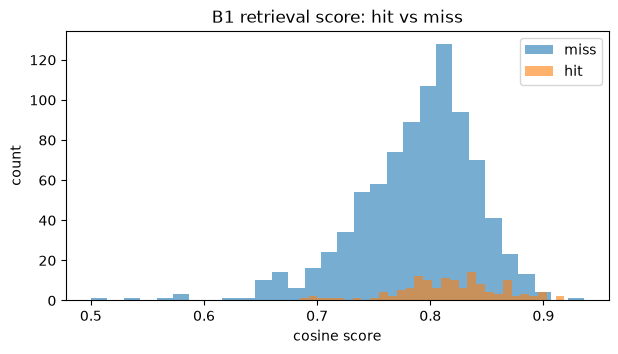

In [3]:
def norm(u):
    if not u:
        return u
    u = re.sub(r'^https?://', '', u.strip().lower())
    return u.replace('en.m.wikipedia.org', 'en.wikipedia.org').rstrip('/')

gt = {x['unique_id']: norm(x.get('wikipedia_url'))
      for x in json.load(open(BASE + '/encyclopedic_test_subset.json'))}

hit, miss = [], []
for p in preds:
    rc = p.get('retrieved_context') or {}
    r = norm(rc.get('wiki_url'))
    (hit if r and r == gt.get(p['unique_id']) else miss).append(rc.get('score'))
hs = [x for x in hit if x is not None]; ms = [x for x in miss if x is not None]
print('hit@1: %d / %d = %.1f%%' % (len(hit), len(preds), 100 * len(hit) / len(preds)))
print('score  hit mean %.3f | miss mean %.3f' % (mean(hs), mean(ms)))

plt.figure(figsize=(7, 3.5))
plt.hist(ms, bins=30, alpha=0.6, label='miss')
plt.hist(hs, bins=30, alpha=0.6, label='hit')
plt.xlabel('cosine score'); plt.ylabel('count'); plt.legend()
plt.title('B1 retrieval score: hit vs miss'); plt.show()

In [4]:
# Ground truth vs retrieved article (often a visually related species)
def title(u):
    return (u or '').split('/wiki/')[-1]
print('%-26s %-26s %6s' % ('ground truth', 'retrieved', 'score'))
for p in preds[:10]:
    rc = p.get('retrieved_context') or {}
    print('%-26s %-26s %6.3f' % (title(gt.get(p['unique_id']))[:26],
                                 title(norm(rc.get('wiki_url')))[:26], rc.get('score') or 0))

ground truth               retrieved                   score
arabidopsis_lyrata         cardamine_nuttallii         0.810
savannah_sparrow           melospiza                   0.762
phyllanthus_urinaria       mananambal                  0.848
terry_park_ballfield       old_palm_beach_junior_coll  0.817
psychotria_nervosa         piper_darienense            0.847
japanese_beetle            anomala                     0.818
savannah_sparrow           nightingale_island_finch    0.759
argiope_appensa            argiope_catenulata          0.840
arabidopsis_lyrata         eruca                       0.816
long-toed_salamander       blackbelly_salamander       0.871


## Pros / cons / limitations

**Pros**
- Simplest possible RAG; no extra model calls beyond one image encode.
- Grounded: Qwen often states when the context is unrelated instead of hallucinating.

**Cons**
- Top-1 exact-article accuracy ~13% → most examples get the wrong context.
- First-3 sections may not contain the answer even when the article is correct.
- The question is ignored during retrieval and during paragraph selection.

**Limitations**
- Fine-grained retrieval: neighbours are visually related species/genera, so top-1 rarely nails the exact entity.
- Single retrieved article → no recovery when top-1 is wrong.

**Next levers:** raise top-k (recall), feed all sections, re-enable question-aware reranking.